In [63]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
print(df.shape)        # (7043, 21)
print(df['Churn'].value_counts(normalize=True))

(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [64]:
import numpy as np
import matplotlib.pyplot as plt

In [65]:
y=df.Churn

In [66]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn']

In [67]:
df.head

<bound method NDFrame.head of       customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL   

<Axes: xlabel='Churn'>

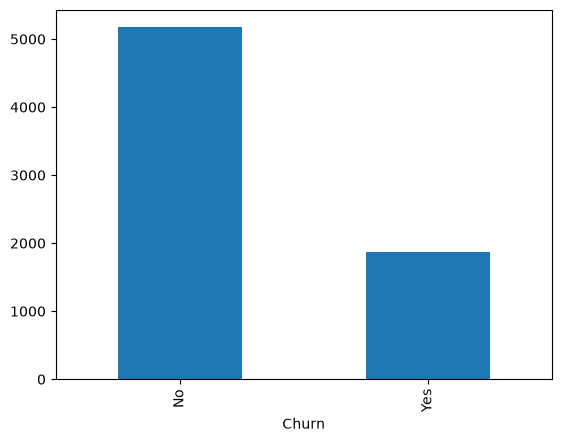

In [68]:
#Checking Class Balance: Dependent Variable Bar Graph Analysis:
#Plot the dependent variable on a bar graph to check if the classes are balanced or imbalanced.

y.value_counts().plot(kind='bar')

In [69]:
#Handling Class Imbalance with SMOTE
# Use the SMOTE method to address class imbalance by using parameter - random_state = 100.

from sklearn.preprocessing import LabelEncoder

# Drop customerID if present
df = df.drop(columns=['customerID'], errors='ignore')

# Fix TotalCharges (whitespace strings → NaN → drop)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna()

# Encode target
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode all remaining categorical columns
df = pd.get_dummies(df, drop_first=True)

# Now apply SMOTE
X = df.drop(columns=['Churn'])
y = df['Churn']

smote = SMOTE(random_state=100)
X_smote, y_smote = smote.fit_resample(X, y)

print('Original dataset shape:', len(df))
print('Resampled dataset shape:', len(y_smote))

Original dataset shape: 7032
Resampled dataset shape: 10326


In [70]:
#Standardization of Customer Churn Independent Variables using Standard Scaler */
# Do Standardization on the customer churn independent variables dataset using the Standard Scaler method.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_smote_scaled = scaler.fit_transform(X_smote)

In [25]:
#Splitting Dataset into Training and Testing Subsets
#Split the dataset into training and testing subsets by using the following parameters - train_size = 0.7, test_size = 0.3 , random_state = 100.
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_smote_scaled, y_smote, test_size=0.2, random_state=42
)

In [30]:
#Training Logistic Regression : Train a logistic regression model on the training dataset and set random_state = 100.

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
ypred_lr = lr.predict(X_test)

In [34]:
#Training Support Vector Machine Model: Train a Support Vector Machine model on the training dataset using the following parameters - kernel="rbf", random_state=100.
from sklearn.svm import SVC

svm = SVC(kernel="rbf", random_state=42)
svm.fit(X_train, y_train)
ypred_svm = svm.predict(X_test)

In [41]:
# Training the Decision Tree Model
#Train a Decision Tree model on the training dataset using the following parameters - criterion="gini", max_leaf_nodes=50.

from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(criterion="gini", max_leaf_nodes=50)
dt.fit(X_train, y_train)
ypred_dt = dt.predict(X_test)                           

In [42]:
#Training the Xgboost Model
#Train an Xgboost model on the training dataset by using parameter - max_depth = 2 and random_state = 100.

from xgboost import XGBClassifier

xgb = XGBClassifier(max_depth = 2, random_state=42)
xgb.fit(X_train, y_train)
ypred_xgb = xgb.predict(X_test)

In [43]:
#Evaluation Performance of Each Model on Test Dataset using Confusion Matrix
#Evaluate the performance of each model on the test dataset using the confusion matrix.
from sklearn.metrics import confusion_matrix
cm1 = confusion_matrix(y_test, ypred_lr)
cm1

array([[874, 163],
       [175, 854]])

In [44]:
cm2 = confusion_matrix(y_test, ypred_svm)
cm2

array([[891, 146],
       [188, 841]])

In [45]:
cm3 = confusion_matrix(y_test, ypred_dt)
cm3

array([[818, 219],
       [179, 850]])

In [46]:
cm4 = confusion_matrix(y_test, ypred_xgb)
cm4

array([[855, 182],
       [155, 874]])

In [47]:
#Evaluate Each Model on Test Dataset Using Accuracy Score
#Evaluate the performance of each model on the test dataset using the accuracy score
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(y_test, ypred_lr)
ac1

0.8363988383349468

In [48]:
ac2 = accuracy_score(y_test, ypred_svm)
ac2

0.8383349467570184

In [49]:
ac3 = accuracy_score(y_test, ypred_dt)
ac3

0.8073572120038722

In [50]:
ac4 = accuracy_score(y_test, ypred_xgb)
ac4

0.8368828654404646

In [51]:
#Hyperparameter Tuning for Xgboost Model using Grid Search CV
#Perform hyperparameter tuning for a machine learning model that has highest accuracy i.e. XGBoost to further improve the performance of the model in predicting customer churn. Use the following parameters in the grid search: cv - 'learning_rate': [0.1, 0.01], 'max_depth': [5, 7], 'n_estimators': [200, 300], 'subsample': [0.8, 0.9].
from sklearn.model_selection import GridSearchCV
model = XGBClassifier()
param_grid = {
'learning_rate': [0.1, 0.01],
'max_depth': [5, 7],
'n_estimators': [200, 300,],
'subsample': [0.8, 0.9]
}
grid_search = GridSearchCV(model, param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

{'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}


In [54]:
xgb_model_hp = XGBClassifier(learning_rate=0.1, max_depth= 7, n_estimators =300, subsample=0.9,random_state = 100)
xgb_model_hp.fit(X_train, y_train)

ypred_xgb_hp=xgb_model_hp.predict(X_test)
y_pred_proba_xgb_hp = xgb_model_hp.predict_proba(X_test)[:, 1]

In [58]:
#Evaluate the performance of the best Xgboost model using the following metrics - confusion matrix, accuracy score and roc auc score and plot auc roc curve.
from sklearn.metrics import roc_curve,roc_auc_score
cm5=confusion_matrix(y_test ,ypred_xgb_hp)
cm5

array([[891, 146],
       [160, 869]])

In [57]:
print(grid_search.best_score_)

0.8468523002421307


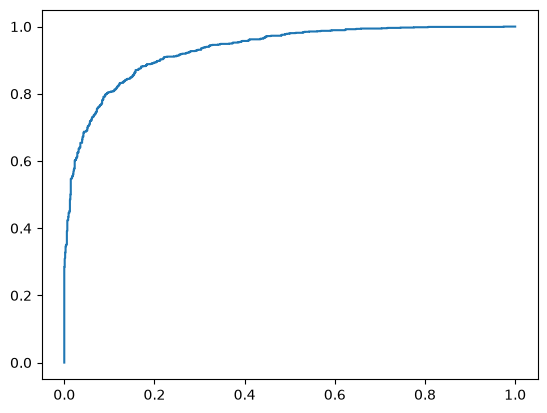

In [61]:
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb_hp)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, y_pred_proba_xgb_hp)
plt.plot(xgb_fpr, xgb_tpr, label='XGBoost (AUC = %.2f)' % xgb_auc)